In [1]:
# ============================================================
#  DELIVERY ROUTE OPTIMIZATION – France
#  Algorithms : Dijkstra | BFS | DFS | Greedy Nearest-Neighbor
#  Signatures :
#    1. Delivery Prediction Module     – Raed Meddeb
#    2. Interactive Chatbot            – Sadok Tlili
#    3. K-Means Driver Assignment      – Ibrahim Grira
#    4. Dynamic Road Weight Modifier   – Ahmed Frouja
#    5. Geographic Network Visualization – Koussay Ibn Haj Kacem
# ============================================================

In [2]:
#IMPORTING THE LIBRAIRIES WE'RE GOING TO WORK WITH

In [3]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.cluster import KMeans
import numpy as np

In [4]:
# UTILITY – read quoted CSV files
# ------------------------------------------------------------
def read_csv(path):
    rows = []
    with open(path, encoding='latin1') as f:
        for line in f:
            rows.append(line.strip().strip('"'))
    header = rows[0].split(',')
    data   = [r.split(',') for r in rows[1:] if r]
    return pd.DataFrame(data, columns=header)

In [5]:
# 1. LOAD DATA
# ============================================================
cities_df   = read_csv("cities.csv")
distance_df = read_csv("distance.csv")
delivery_df = read_csv("delivery.csv")

distance_df['distance_km'] = distance_df['distance_km'].astype(float)
cities_df['latitude']      = cities_df['latitude'].astype(float)
cities_df['longitude']     = cities_df['longitude'].astype(float)

print("Cities loaded    :", len(cities_df))
print("Roads loaded     :", len(distance_df))
print("Deliveries loaded:", len(delivery_df))

Cities loaded    : 20
Roads loaded     : 31
Deliveries loaded: 20


In [6]:
# 2. BUILD THE GRAPH
# ============================================================
G = nx.Graph()

for _, row in cities_df.iterrows():
    G.add_node(row['city'], lat=row['latitude'], lon=row['longitude'])

for _, row in distance_df.iterrows():
    G.add_edge(row['source'], row['destination'], weight=row['distance_km'])

# Keep a backup of original weights (used by Signature 4)
original_weights = {(u, v): d['weight'] for u, v, d in G.edges(data=True)}

ALL_CITIES = list(cities_df['city'])

print(f"\nGraph  →  {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")


Graph  →  20 nodes, 30 edges


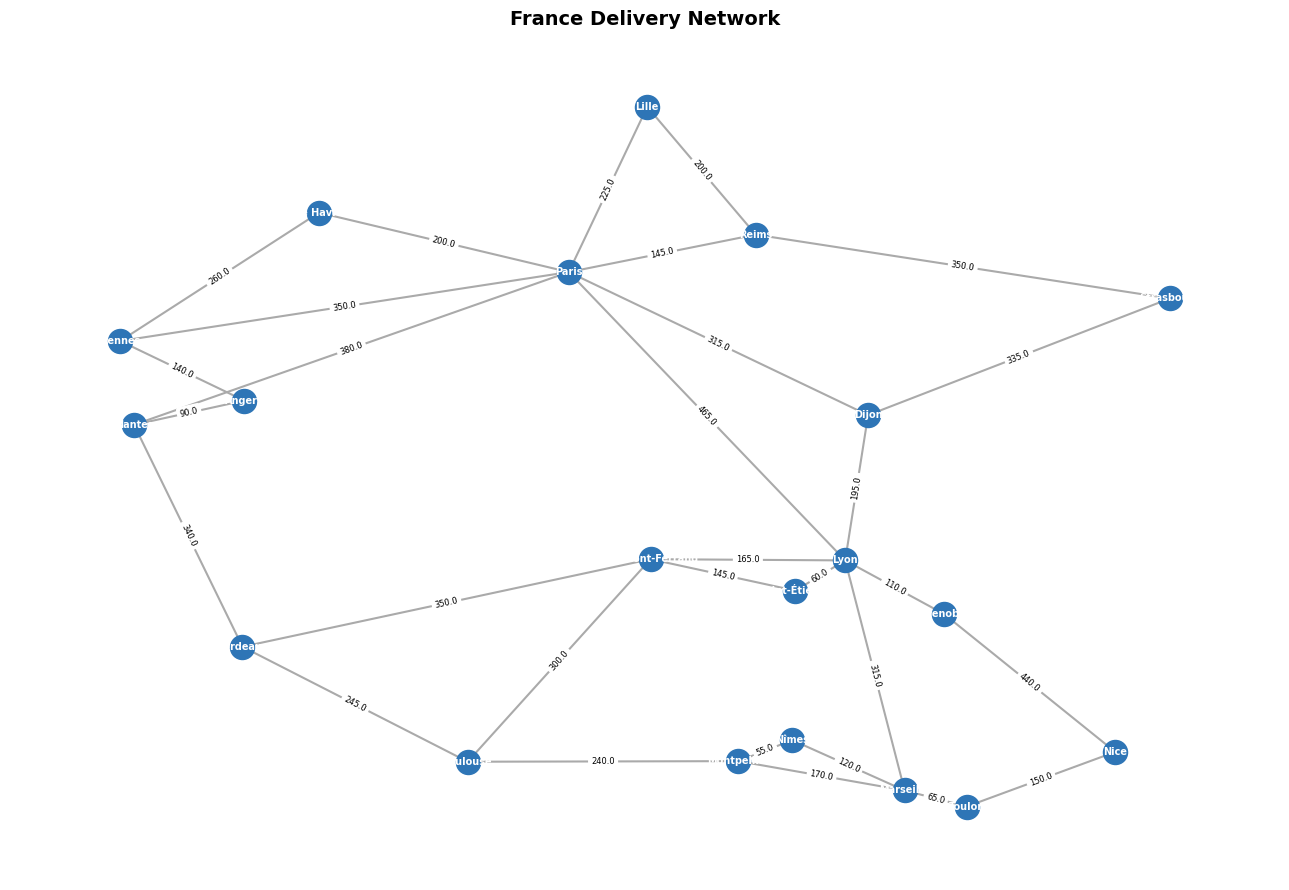

In [7]:
# 3. VISUALIZE THE NETWORK   ← Signature 5 – Koussay Ibn Haj Kacem
# ============================================================
pos = {row['city']: (row['longitude'], row['latitude'])
       for _, row in cities_df.iterrows()}

plt.figure(figsize=(13, 9))
nx.draw_networkx_nodes(G, pos, node_size=300, node_color='#2E75B6')
nx.draw_networkx_labels(G, pos, font_size=7, font_color='white', font_weight='bold')
nx.draw_networkx_edges(G, pos, edge_color='#AAAAAA', width=1.5)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6)
plt.title("France Delivery Network", fontsize=14, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.savefig("network.png", dpi=150)
plt.show()

In [8]:
# 4. DIJKSTRA – SHORTEST PATH
# ============================================================
def shortest_path(source, target):
    try:
        path = nx.dijkstra_path(G, source, target, weight='weight')
        dist = nx.dijkstra_path_length(G, source, target, weight='weight')
        return path, round(dist, 2)
    except Exception:
        return None, None


print("\n=== DIJKSTRA – SHORTEST PATHS ===")
for src, tgt in [("Paris","Marseille"), ("Paris","Nice"),
                 ("Lille","Toulouse"),  ("Nantes","Strasbourg")]:
    path, dist = shortest_path(src, tgt)
    if path:
        print(f"  {src} → {tgt}")
        print(f"    Path     : {' → '.join(path)}")
        print(f"    Distance : {dist} km\n")



=== DIJKSTRA – SHORTEST PATHS ===
  Paris → Marseille
    Path     : Paris → Lyon → Marseille
    Distance : 780.0 km

  Paris → Nice
    Path     : Paris → Lyon → Marseille → Toulon → Nice
    Distance : 995.0 km

  Lille → Toulouse
    Path     : Lille → Paris → Lyon → Clermont-Ferrand → Toulouse
    Distance : 1155.0 km

  Nantes → Strasbourg
    Path     : Nantes → Paris → Reims → Strasbourg
    Distance : 875.0 km



In [9]:
# 5. BFS – BREADTH-FIRST TRAVERSAL
# ============================================================
def bfs(start):
    return list(nx.bfs_tree(G, start).nodes())

print("=== BFS from Paris ===")
print(" → ".join(bfs("Paris")), "\n")


=== BFS from Paris ===
Paris → Lyon → Lille → Reims → Le Havre → Rennes → Nantes → Dijon → Marseille → Grenoble → Saint-Étienne → Clermont-Ferrand → Strasbourg → Angers → Bordeaux → Toulon → Montpellier → Nîmes → Nice → Toulouse 



In [10]:
# 6. DFS – DEPTH-FIRST TRAVERSAL
# ============================================================
def dfs(start):
    return list(nx.dfs_preorder_nodes(G, start))

print("=== DFS from Paris ===")
print(" → ".join(dfs("Paris")), "\n")

=== DFS from Paris ===
Paris → Lyon → Marseille → Toulon → Nice → Grenoble → Montpellier → Nîmes → Toulouse → Bordeaux → Nantes → Angers → Rennes → Le Havre → Clermont-Ferrand → Saint-Étienne → Dijon → Strasbourg → Reims → Lille 



=== DELIVERY ORDER from Paris ===
  City                   Leg km   Total km
  ------------------------------------------
  Lyon                    465.0      465.0
  Marseille               315.0      780.0
  Nice                    215.0      995.0
  Toulouse                625.0     1620.0
  Bordeaux                245.0     1865.0
  Strasbourg             1045.0     2910.0

  Grand total: 2910.0 km



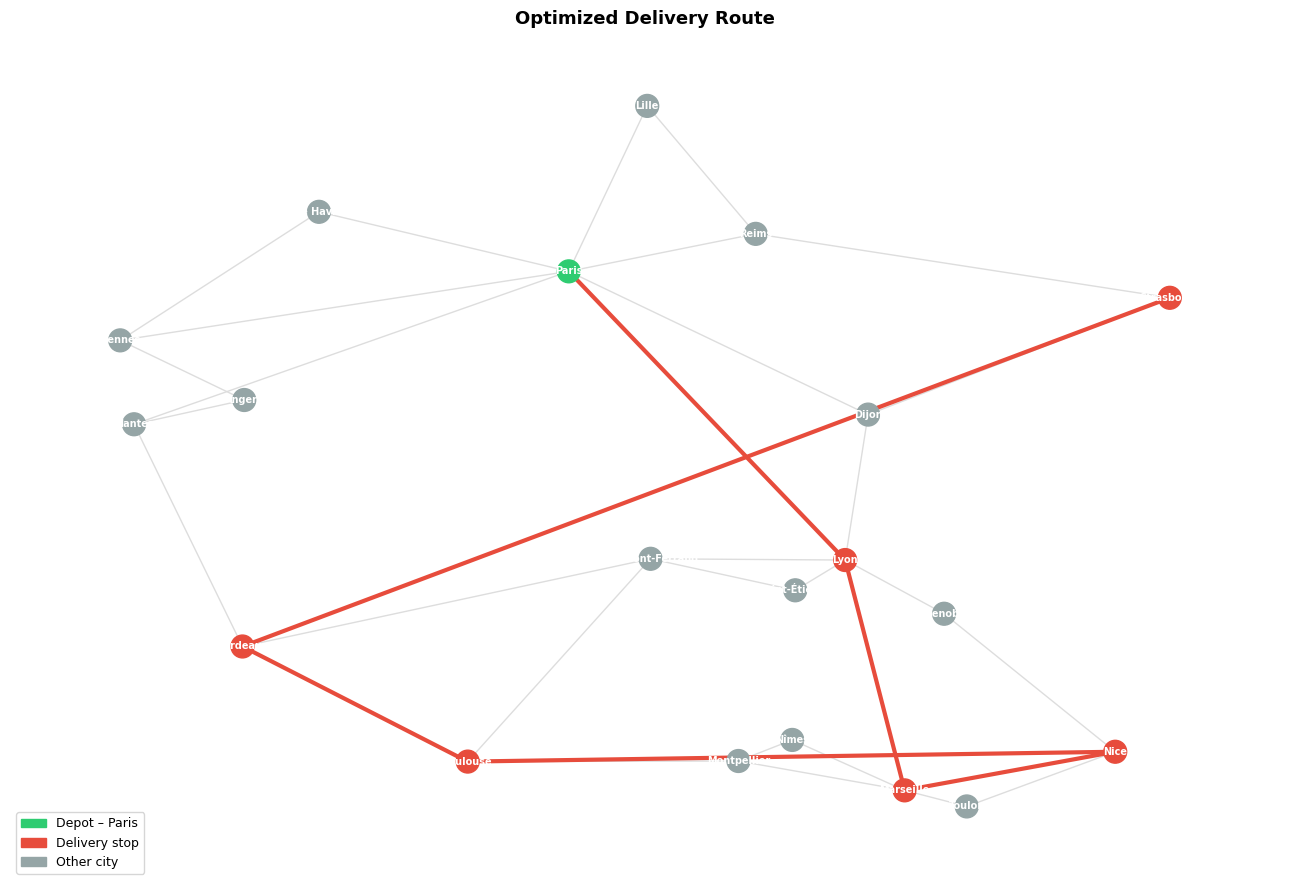

In [13]:
#7.DELIVERY ORDER OPTIMIZATION  (greedy nearest-neighbor)
# ============================================================
def optimize_deliveries(depot, stops):
    current   = depot
    remaining = stops.copy()
    result    = []
    total     = 0.0
    while remaining:
        nearest = min(remaining,
                      key=lambda c: nx.dijkstra_path_length(G, current, c, weight='weight'))
        leg     = nx.dijkstra_path_length(G, current, nearest, weight='weight')
        total  += leg
        result.append((nearest, round(leg, 2), round(total, 2)))
        current = nearest
        remaining.remove(nearest)
    return result


stops  = ["Lyon", "Marseille", "Toulouse", "Bordeaux", "Nice", "Strasbourg"]
result = optimize_deliveries("Paris", stops)

print("=== DELIVERY ORDER from Paris ===")
print(f"  {'City':<20} {'Leg km':>8}  {'Total km':>9}")
print("  " + "-" * 42)
for city, leg, total in result:
    print(f"  {city:<20} {leg:>8}  {total:>9}")
print(f"\n  Grand total: {result[-1][2]} km\n")


# ============================================================
# 8. VISUALIZE THE DELIVERY ROUTE  ← Signature 5 – Koussay Ibn Haj Kacem
# ============================================================
route_order = ["Paris"] + [r[0] for r in result]
route_edges = list(zip(route_order, route_order[1:]))

colors = []
for node in G.nodes():
    if node == "Paris":      colors.append("#2ECC71")
    elif node in stops:      colors.append("#E74C3C")
    else:                    colors.append("#95A5A6")

plt.figure(figsize=(13, 9))
nx.draw_networkx_edges(G, pos, edge_color='#DDDDDD', width=1)
nx.draw_networkx_edges(G, pos, edgelist=route_edges, edge_color='#E74C3C', width=3)
nx.draw_networkx_nodes(G, pos, node_size=270, node_color=colors)
nx.draw_networkx_labels(G, pos, font_size=7, font_color='white', font_weight='bold')
plt.legend(handles=[
    mpatches.Patch(color='#2ECC71', label='Depot – Paris'),
    mpatches.Patch(color='#E74C3C', label='Delivery stop'),
    mpatches.Patch(color='#95A5A6', label='Other city'),
], loc='lower left', fontsize=9)
plt.title("Optimized Delivery Route", fontsize=13, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.savefig("delivery_route.png", dpi=150)
plt.show()


In [14]:
# ============================================================
# SIGNATURE 1 – DELIVERY PREDICTION MODULE
# Raed Meddeb
# ============================================================
#  Given a route + conditions (day, weather, period) the module
#  estimates travel time, delivery cost, and delay risk.
#
#  traffic_factor  = f(day) × f(weather) × f(period)
#  effective_speed = 90 km/h ÷ traffic_factor
#  travel_time     = distance ÷ effective_speed
#  cost            = distance × 0.15 €/km × traffic_factor
#  risk            = LOW (<1.2) | MEDIUM (1.2–1.5) | HIGH (>1.5)
# ------------------------------------------------------------

SPEED     = 90.0
FUEL_RATE = 0.15

DAY_FACTOR     = {"monday":1.35,"tuesday":1.20,"wednesday":1.15,
                  "thursday":1.20,"friday":1.45,"saturday":0.95,"sunday":0.85}
WEATHER_FACTOR = {"clear":1.00,"rain":1.25,"snow":1.65}
PERIOD_FACTOR  = {"normal":1.00,"rush_hour":1.30,"holiday":0.85}


def estimate(source, target, day="monday", weather="clear", period="normal"):
    path, dist = shortest_path(source, target)
    if path is None:
        print(f"  No route found between {source} and {target}.")
        return
    tf        = round(DAY_FACTOR.get(day.lower(),1.0) *
                      WEATHER_FACTOR.get(weather.lower(),1.0) *
                      PERIOD_FACTOR.get(period.lower(),1.0), 2)
    eff_speed = SPEED / tf
    time_h    = dist / eff_speed
    hours, minutes = int(time_h), int((time_h - int(time_h)) * 60)
    cost      = round(dist * FUEL_RATE * tf, 2)
    risk      = "HIGH" if tf >= 1.50 else ("MEDIUM" if tf >= 1.20 else "LOW")

    print(f"  Route      : {' → '.join(path)}")
    print(f"  Distance   : {dist} km")
    print(f"  Conditions : {day.title()}, {weather}, {period.replace('_',' ')}")
    print(f"  Traffic ×  : {tf}")
    print(f"  Travel time: {hours}h{minutes:02d}")
    print(f"  Est. cost  : {cost} €")
    print(f"  Delay risk : {risk}\n")


print("=== SIGNATURE 1 – PREDICTION MODULE (Raed Meddeb) ===\n")
estimate("Paris",  "Marseille", day="monday",    weather="clear", period="rush_hour")
estimate("Paris",  "Marseille", day="sunday",    weather="clear", period="normal")
estimate("Lille",  "Toulouse",  day="friday",    weather="rain",  period="rush_hour")
estimate("Nantes", "Nice",      day="wednesday", weather="snow",  period="normal")


=== SIGNATURE 1 – PREDICTION MODULE (Raed Meddeb) ===

  Route      : Paris → Lyon → Marseille
  Distance   : 780.0 km
  Conditions : Monday, clear, rush hour
  Traffic ×  : 1.76
  Travel time: 15h15
  Est. cost  : 205.92 €
  Delay risk : HIGH

  Route      : Paris → Lyon → Marseille
  Distance   : 780.0 km
  Conditions : Sunday, clear, normal
  Traffic ×  : 0.85
  Travel time: 7h21
  Est. cost  : 99.45 €
  Delay risk : LOW

  Route      : Lille → Paris → Lyon → Clermont-Ferrand → Toulouse
  Distance   : 1155.0 km
  Conditions : Friday, rain, rush hour
  Traffic ×  : 2.36
  Travel time: 30h17
  Est. cost  : 408.87 €
  Delay risk : HIGH

  Route      : Nantes → Bordeaux → Toulouse → Montpellier → Marseille → Toulon → Nice
  Distance   : 1210.0 km
  Conditions : Wednesday, snow, normal
  Traffic ×  : 1.9
  Travel time: 25h32
  Est. cost  : 344.85 €
  Delay risk : HIGH



In [15]:
# ============================================================
# SIGNATURE 2 – INTERACTIVE CHATBOT
# Sadok Tlili
# ============================================================
#  Text-based chatbot letting any user query routes, traversals,
#  and trigger the prediction module through natural commands.
# ------------------------------------------------------------

def chatbot():
    HELP = """
  Commands:
    best route from <City> to <City>    – shortest path (Dijkstra)
    bfs from <City>                     – breadth-first traversal
    dfs from <City>                     – depth-first traversal
    predict from <City> to <City>       – cost & time estimate
    exit                                – quit
    """
    print("\n" + "="*52)
    print("  DELIVERY CHATBOT  –  Sadok Tlili")
    print("="*52)
    print(HELP)

    while True:
        try:
            msg = input("You: ").strip()
        except (EOFError, KeyboardInterrupt):
            break
        if not msg: continue
        low = msg.lower()

        if low == "exit":
            print("Bot: Goodbye!"); break

        elif "best route from" in low:
            try:
                rest  = low.split("best route from",1)[1].strip()
                parts = rest.split(" to ",1)
                src   = parts[0].strip().title()
                tgt   = parts[1].strip().title()
                path, dist = shortest_path(src, tgt)
                if path:
                    print(f"Bot: {' → '.join(path)}  ({dist} km)")
                else:
                    print("Bot: Route not found.")
            except Exception:
                print("Bot: Use  'best route from Paris to Nice'")

        elif low.startswith("bfs from"):
            city = msg[8:].strip().title()
            order = bfs(city)
            print("Bot:", " → ".join(order) if order else "City not found.")

        elif low.startswith("dfs from"):
            city = msg[8:].strip().title()
            order = dfs(city)
            print("Bot:", " → ".join(order) if order else "City not found.")

        elif "predict from" in low:
            try:
                rest  = low.split("predict from",1)[1].strip()
                parts = rest.split(" to ",1)
                src   = parts[0].strip().title()
                tgt   = parts[1].strip().title()
                day     = input("Bot: Day (e.g. monday)          : ").strip().lower() or "monday"
                weather = input("Bot: Weather (clear/rain/snow)  : ").strip().lower() or "clear"
                period  = input("Bot: Period (normal/rush_hour)  : ").strip().lower() or "normal"
                estimate(src, tgt, day, weather, period)
            except Exception:
                print("Bot: Use  'predict from Paris to Lyon'")

        else:
            print("Bot: Type 'help' for available commands.")

In [16]:
# ============================================================
# SIGNATURE 3 – K-MEANS DRIVER ASSIGNMENT
# Ibrahim Grira
# ============================================================
#  Clusters delivery cities geographically using K-Means so
#  each driver covers a compact, non-overlapping zone.
#  Within each cluster the nearest-neighbor heuristic orders
#  the stops and Dijkstra computes the leg distances.
# ------------------------------------------------------------

def assign_drivers(num_drivers=2):
    coords  = cities_df[['latitude','longitude']].values
    cities  = cities_df['city'].tolist()

    km      = KMeans(n_clusters=num_drivers, random_state=42, n_init=10)
    labels  = km.fit_predict(coords)
    centroids = km.cluster_centers_

    print(f"\n=== SIGNATURE 3 – K-MEANS DRIVER ASSIGNMENT (Ibrahim Grira) ===")
    print(f"    {num_drivers} drivers, {len(cities)} cities\n")

    for drv in range(num_drivers):
        indices       = [i for i,l in enumerate(labels) if l == drv]
        cluster_cities = [cities[i] for i in indices]
        cluster_coords = coords[indices]

        # Pick depot as city closest to centroid
        dists  = np.linalg.norm(cluster_coords - centroids[drv], axis=1)
        depot  = cluster_cities[int(np.argmin(dists))]
        others = [c for c in cluster_cities if c != depot]

        # Greedy order within cluster
        ordered = optimize_deliveries(depot, others)
        total   = ordered[-1][2] if ordered else 0

        print(f"  Driver {drv+1}  |  Depot: {depot}  |  Stops: {len(others)}")
        print(f"    Route : {depot} → " + " → ".join(c for c,_,_ in ordered))
        print(f"    Total : {total} km\n")


In [17]:
# ============================================================
# SIGNATURE 4 – DYNAMIC ROAD WEIGHT MODIFICATION
# Ahmed Frouja
# ============================================================
#  Lets the user temporarily change edge weights to simulate
#  road closures, traffic jams, or construction.
#  All changes can be reverted in one call.
# ------------------------------------------------------------

def modify_road(source, target, new_weight):
    """Change the weight of a road segment."""
    if G.has_edge(source, target):
        G[source][target]['weight'] = new_weight
        G[target][source]['weight'] = new_weight
        print(f"  Road {source} ↔ {target} updated to {new_weight} km")
    else:
        print(f"  No direct road between {source} and {target}.")

def restore_weights():
    """Reset all weights to their original values."""
    for (u,v), w in original_weights.items():
        if G.has_edge(u,v):
            G[u][v]['weight'] = w
            G[v][u]['weight'] = w
    print("  All road weights restored to original values.")


print("=== SIGNATURE 4 – DYNAMIC ROAD WEIGHT MODIFIER (Ahmed Frouja) ===\n")

# Demo: close the Paris–Lyon motorway (simulate accident)
path_before, dist_before = shortest_path("Paris", "Marseille")
print(f"  Before modification : {' → '.join(path_before)}  ({dist_before} km)")

modify_road("Paris", "Lyon", 9999)   # simulate closure

path_after, dist_after = shortest_path("Paris", "Marseille")
print(f"  After  modification : {' → '.join(path_after)}  ({dist_after} km)")

restore_weights()
path_restored, dist_restored = shortest_path("Paris", "Marseille")
print(f"  After  restore      : {' → '.join(path_restored)}  ({dist_restored} km)\n")

=== SIGNATURE 4 – DYNAMIC ROAD WEIGHT MODIFIER (Ahmed Frouja) ===

  Before modification : Paris → Lyon → Marseille  (780.0 km)
  Road Paris ↔ Lyon updated to 9999 km
  After  modification : Paris → Dijon → Lyon → Marseille  (825.0 km)
  All road weights restored to original values.
  After  restore      : Paris → Lyon → Marseille  (780.0 km)



=== SIGNATURE 5 – GEOGRAPHIC VISUALIZATION (Koussay Ibn Haj Kacem) ===



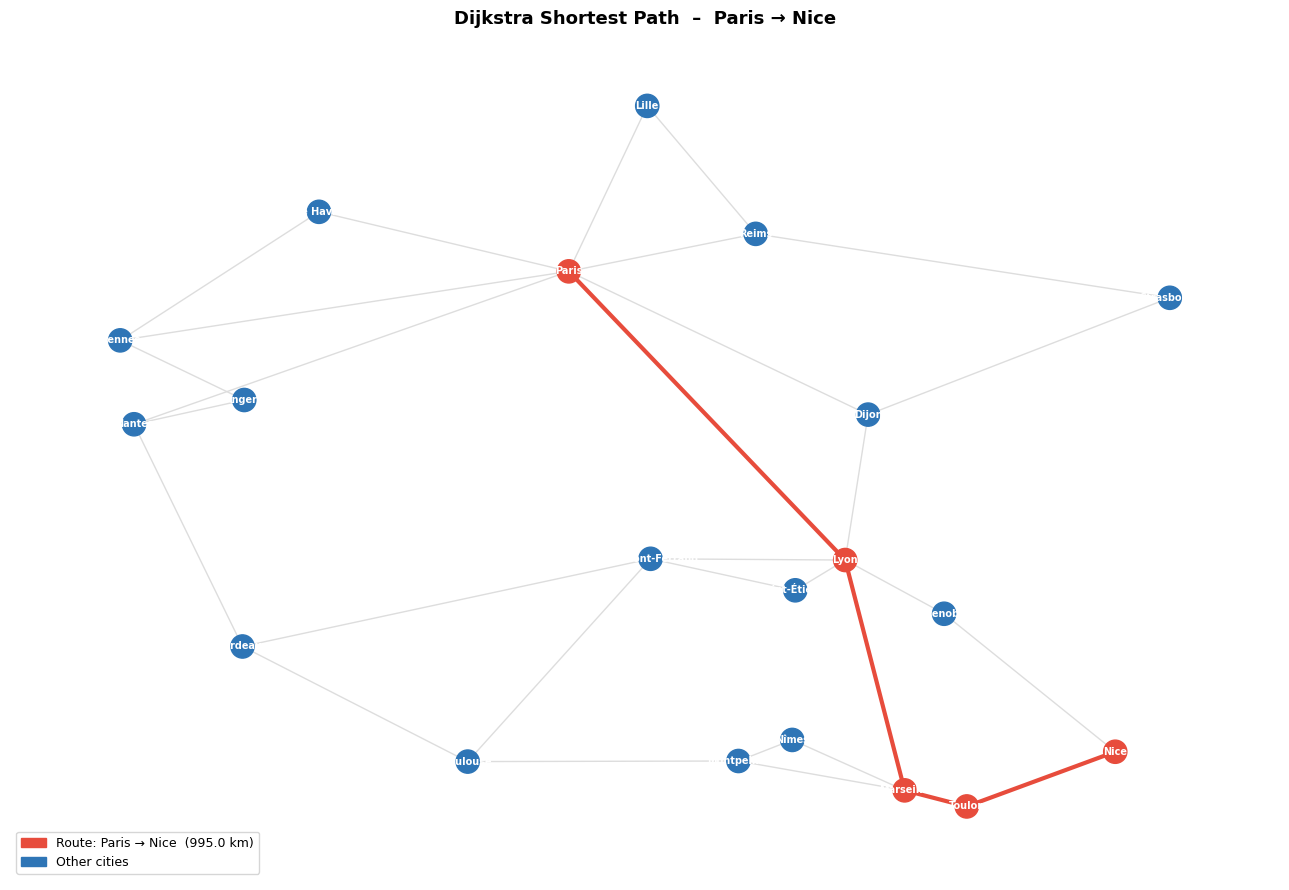

  Map saved: route_paris_nice.png



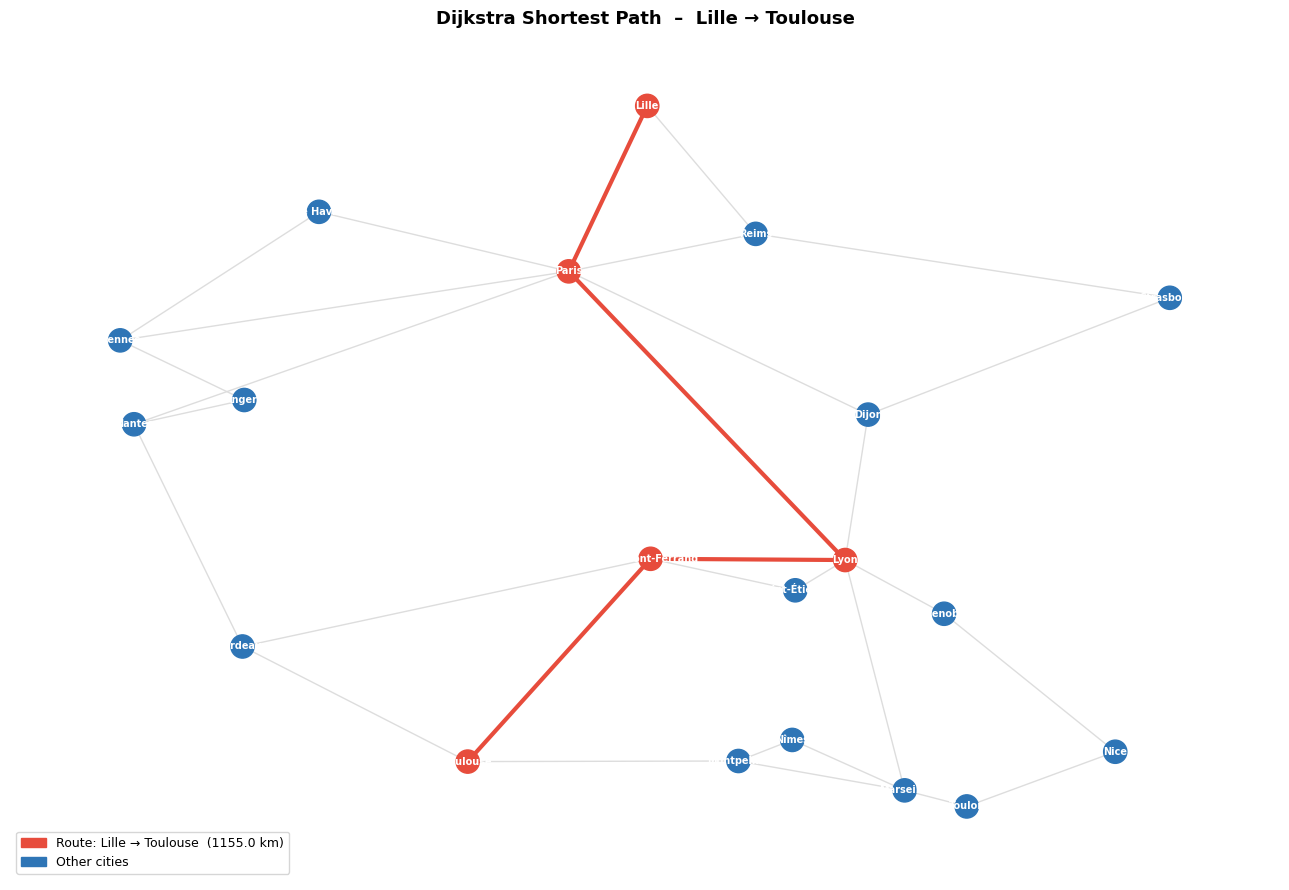

  Map saved: route_lille_toulouse.png



In [18]:
# ============================================================
# SIGNATURE 5 – GEOGRAPHIC NETWORK VISUALIZATION
# Koussay Ibn Haj Kacem
# ============================================================
#  Plots the delivery network on a geographically accurate map
#  using real GPS coordinates (latitude/longitude as x/y).
#  A second map highlights any specific route in red.
# ------------------------------------------------------------

def visualize_route(source, target, title="Route Highlight"):
    """Plot the full network and highlight a specific path in red."""
    path, dist = shortest_path(source, target)
    if not path:
        print(f"  No route found from {source} to {target}.")
        return

    route_edges = list(zip(path, path[1:]))
    node_colors = ['#E74C3C' if n in path else '#2E75B6' for n in G.nodes()]

    plt.figure(figsize=(13, 9))
    nx.draw_networkx_edges(G, pos, edge_color='#DDDDDD', width=1)
    nx.draw_networkx_edges(G, pos, edgelist=route_edges, edge_color='#E74C3C', width=3)
    nx.draw_networkx_nodes(G, pos, node_size=280, node_color=node_colors)
    nx.draw_networkx_labels(G, pos, font_size=7, font_color='white', font_weight='bold')
    plt.legend(handles=[
        mpatches.Patch(color='#E74C3C', label=f'Route: {source} → {target}  ({dist} km)'),
        mpatches.Patch(color='#2E75B6', label='Other cities'),
    ], loc='lower left', fontsize=9)
    plt.title(f"{title}  –  {source} → {target}", fontsize=13, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    fname = f"route_{source.lower()}_{target.lower()}.png"
    plt.savefig(fname, dpi=150)
    plt.show()
    print(f"  Map saved: {fname}\n")


print("=== SIGNATURE 5 – GEOGRAPHIC VISUALIZATION (Koussay Ibn Haj Kacem) ===\n")
visualize_route("Paris", "Nice",        title="Dijkstra Shortest Path")
visualize_route("Lille", "Toulouse",    title="Dijkstra Shortest Path")


In [ ]:
# ============================================================
# MAIN – run all signatures + interactive tools
# ============================================================
if __name__ == "__main__":
    print("\n" + "="*52)
    print("  Choose what to run:")
    print("  1 – Interactive Prediction Estimator  (Raed)")
    print("  2 – Chatbot                           (Sadok)")
    print("  3 – K-Means Driver Assignment         (Ibrahim)")
    print("  4 – Dynamic Road Modifier demo        (Ahmed)")
    print("  5 – Visualize a custom route          (Koussay)")
    print("  0 – Exit")
    print("="*52)

    while True:
        try:
            choice = input("\nChoice: ").strip()
        except (EOFError, KeyboardInterrupt):
            break

        if choice == "0":
            break

        elif choice == "1":
            print("\n  Cities:", ", ".join(sorted(G.nodes())))
            src = input("  Departure : ").strip().title()
            tgt = input("  Destination: ").strip().title()
            day     = input("  Day (monday/friday/sunday…): ").strip().lower() or "monday"
            weather = input("  Weather (clear/rain/snow)  : ").strip().lower() or "clear"
            period  = input("  Period (normal/rush_hour)  : ").strip().lower() or "normal"
            estimate(src, tgt, day, weather, period)

        elif choice == "2":
            chatbot()

        elif choice == "3":
            try:
                n = int(input("  Number of drivers: ").strip())
            except ValueError:
                n = 2
            assign_drivers(n)

        elif choice == "4":
            print("  Cities:", ", ".join(sorted(G.nodes())))
            src = input("  Road start : ").strip().title()
            tgt = input("  Road end   : ").strip().title()
            try:
                w = float(input("  New weight (km, use 9999 to close): ").strip())
            except ValueError:
                w = 9999
            modify_road(src, tgt, w)
            p, d = shortest_path(src, tgt)
            print(f"  New shortest path: {' → '.join(p) if p else 'none'}  ({d} km)")
            restore_weights()

        elif choice == "5":
            print("  Cities:", ", ".join(sorted(G.nodes())))
            src = input("  From : ").strip().title()
            tgt = input("  To   : ").strip().title()
            visualize_route(src, tgt)

        else:
            print("  Invalid choice. Enter 0–5.")


  Choose what to run:
  1 – Interactive Prediction Estimator  (Raed)
  2 – Chatbot                           (Sadok)
  3 – K-Means Driver Assignment         (Ibrahim)
  4 – Dynamic Road Modifier demo        (Ahmed)
  5 – Visualize a custom route          (Koussay)
  0 – Exit
